<p align="center">
  <img src="./yibo-quant.jpg" alt="课程封面" width="1300"/>
</p>


# 《和Yibo零基础学习量化金融》
## 从Python到AI量化交易实战 第一期
### 第三章：移动平均线策略

---

## 本章你将学会

- ✅ 区分 **上涨趋势、下跌趋势、噪声**（配图）
- ✅ 理解为什么要用 **移动平均** 看整体走势
- ✅ 计算 **MA5 / MA20 / MA30**，认出 **金叉 / 死叉**
- ✅ 写出第一个规则：`if MA_short > MA_long: 持有`
- ✅ 在图上标 **买点、卖点** 和持仓状态

**当前等级**  
🎮 **Lv.2 策略设计师**

**本章难度**  
⭐⭐☆☆☆

**预计学习时间**  
30～45 分钟（后半段需联网）

**前置知识**

- 完成 **第二章**（收益率、`pct_change`）
- Python 基础、会用 Jupyter

---

从这一章开始，我们真正进入 **「策略」** —— 很多读者最期待的部分：**把看盘直觉写成 if 规则**。

### 环境准备

In [ ]:
# ========== 环境准备 ==========
import warnings
warnings.filterwarnings('ignore')  # 隐藏无关警告

import numpy as np              # 数值计算
import pandas as pd             # 表格数据
import matplotlib.pyplot as plt   # 画图
import yfinance as yf           # 下载股票行情（需联网）
import socket

plt.rcParams['font.sans-serif'] = ['SimHei']   # 图表中文
plt.rcParams['axes.unicode_minus'] = False    # 负号正常

# ========== 自动检测网络，选择数据源（参考第一章实现）==========
PROXY_PORT = 7897                # <-- 代理端口，按实际情况修改
PROXY_HOST = '127.0.0.1'        # <-- 代理地址

def _proxy_ok(host=PROXY_HOST, port=PROXY_PORT, timeout=1):
    """检测代理是否可用"""
    try:
        with socket.create_connection((host, port), timeout=timeout):
            return True
    except (OSError, socket.timeout):
        return False

def _try_yf(ticker, period, proxy_url=None):
    """尝试用 yfinance 下载，成功返回 DataFrame，失败返回 None"""
    import os
    if proxy_url:
        os.environ['HTTP_PROXY']  = proxy_url
        os.environ['HTTPS_PROXY'] = proxy_url
    else:
        # 如果不走代理，清除代理环境变量
        os.environ.pop('HTTP_PROXY', None)
        os.environ.pop('HTTPS_PROXY', None)
    df = yf.download(ticker, period=period, progress=False, multi_level_index=False)
    return df if len(df) > 0 else None

def download_stock(ticker, period='2y'):
    """三级下载策略：直连 → 代理 → AkShare"""
    df, source = None, None
    
    # 优先级 1：直连 yfinance
    try:
        df = _try_yf(ticker, period)
        if df is not None:
            source = 'yfinance (直连)'
    except Exception:
        pass
    
    # 优先级 2：走代理访问 yfinance
    if df is None and _proxy_ok():
        try:
            df = _try_yf(ticker, period, f'http://{PROXY_HOST}:{PROXY_PORT}')
            if df is not None:
                source = 'yfinance (代理)'
        except Exception:
            pass
    
    # 优先级 3：国内直连 AkShare
    if df is None:
        try:
            import akshare as ak
            # 美股代码映射
            symbol_map = {'AAPL': 'AAPL', 'TSLA': 'TSLA', 'NVDA': 'NVDA', 'SPY': 'SPY'}
            ak_symbol = symbol_map.get(ticker, ticker)
            raw = ak.stock_us_daily(symbol=ak_symbol, adjust='qfq')
            raw['date'] = pd.to_datetime(raw['date'])
            df = raw.set_index('date')
            df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']
            # 根据 period 筛选数据
            if period == '1y':
                df = df.tail(252)
            elif period == '2y':
                df = df.tail(504)
            elif period == '6mo':
                df = df.tail(126)
            source = 'AkShare (国内直连)'
        except Exception as e:
            print(f'AkShare 下载也失败: {e}')
    
    return df, source

TICKER = 'AAPL'   # 股票代码，可改成 TSLA、NVDA
PERIOD = '2y'     # 下载多长历史（均线需要足够天数）

print('环境就绪 ✓')


环境就绪 ✓


---

### 3.1 什么是趋势？

打开行情软件，最常听到三个词：

| 说法 | 直觉含义 |
|------|----------|
| **上涨趋势** | 价格整体在往上走，低点越来越高 |
| **下跌趋势** | 价格整体在往下走，高点越来越低 |
| **噪声** | 短期上蹿下跳，像「毛刺」，不一定代表大方向变了 |

量化策略的第一步，就是先把 **大方向（趋势）** 和 **每日乱动（噪声）** 分开。

下面用一段 **模拟价格** 把三种状态画在一起（真实股票也是这三种的混合）。

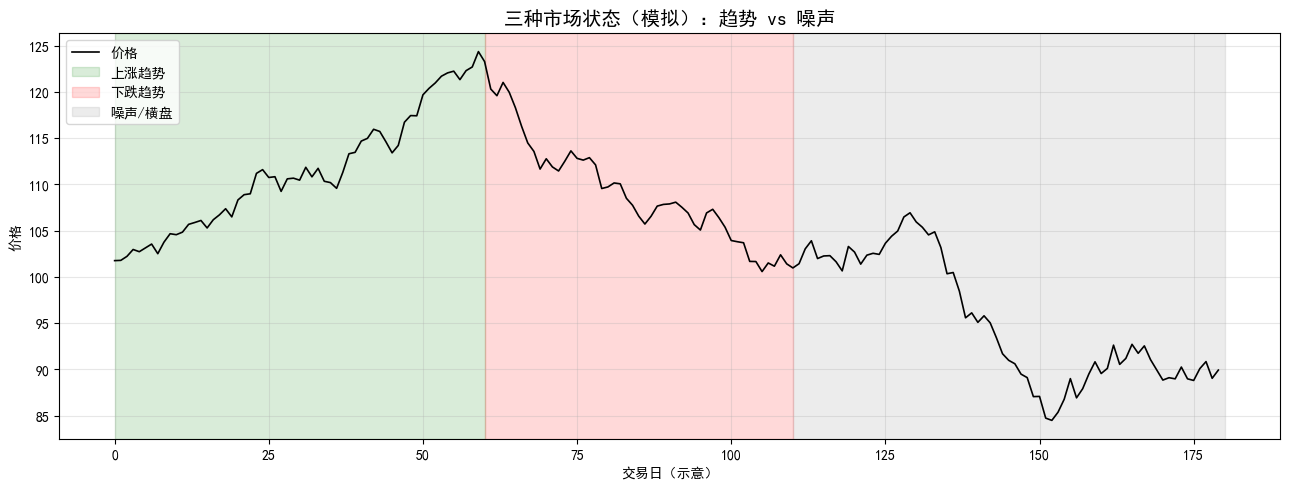

绿色区：整体向上 | 红色区：整体向下 | 灰色区：方向不明显、抖动大


In [2]:
# ========== 模拟三种市场状态并分区上色 ==========
np.random.seed(7)              # 固定随机数，图可复现
n_up, n_down, n_noise = 60, 50, 70  # 上涨段、下跌段、横盘段各多少天

ret_up = np.random.normal(0.004, 0.008, n_up)        # 上涨段：平均日收益偏正
ret_down = np.random.normal(-0.005, 0.010, n_down)   # 下跌段：平均日收益偏负
ret_noise = np.random.normal(0.0, 0.015, n_noise)    # 横盘：均值约0，波动大

price = 100 * np.cumprod(1 + np.r_[ret_up, ret_down, ret_noise])  # 拼成价格
x = np.arange(len(price))  # 横轴：第几个交易日

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(x, price, color='black', linewidth=1.2, label='价格')

ax.axvspan(0, n_up, alpha=0.15, color='green', label='上涨趋势')
ax.axvspan(n_up, n_up + n_down, alpha=0.15, color='red', label='下跌趋势')
ax.axvspan(n_up + n_down, len(price), alpha=0.15, color='gray', label='噪声/横盘')

ax.set_title('三种市场状态（模拟）：趋势 vs 噪声', fontsize=14)
ax.set_xlabel('交易日（示意）')
ax.set_ylabel('价格')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('绿色区：整体向上 | 红色区：整体向下 | 灰色区：方向不明显、抖动大')


---

### 3.2 为什么需要「平均」？

真实股票 **每天波动太乱**：一条消息、一笔大单，都可能让当天收盘价上蹿下跳。

但我们做策略时，更关心：

> **「整体趋势」到底在往上还是往下？**

解决办法很朴素：**把最近几天的价格取平均**，就像把毛刺磨平，留下更平滑的「趋势线」。

这就是 **移动平均线（Moving Average, MA）** 的直觉来源。

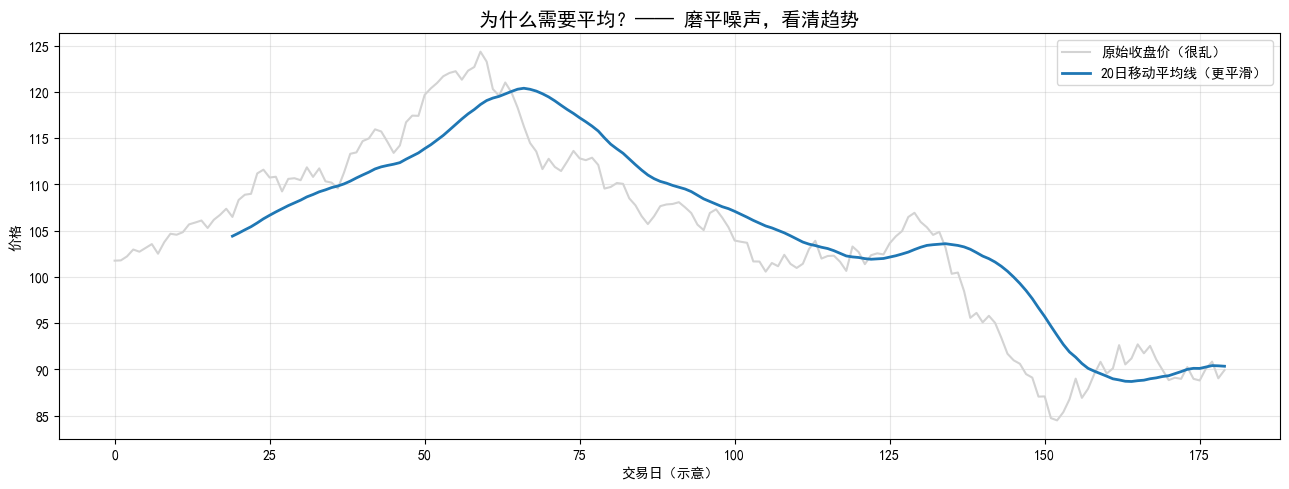

In [3]:
# ========== 对比「乱的价格」和「平滑的均线」==========
demo = pd.DataFrame({'Close': price})           # 用上面模拟的价格
demo['MA20'] = demo['Close'].rolling(20).mean()  # 20日移动平均

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(demo['Close'], label='原始收盘价（很乱）', color='lightgray', linewidth=1.5)
ax.plot(demo['MA20'], label='20日移动平均线（更平滑）', color='tab:blue', linewidth=2)
ax.set_title('为什么需要平均？—— 磨平噪声，看清趋势', fontsize=14)
ax.set_xlabel('交易日（示意）')
ax.set_ylabel('价格')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

### 3.3 移动平均线（核心）

**n 日简单移动平均线** 的定义：最近 n 天收盘价的算术平均。

$$
MA_n(t) = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}
$$

例如 **MA5** = 最近 5 天收盘价的平均；**MA10** = 最近 10 天收盘价的平均；**MA20** = 最近 20 天收盘价的平均；**MA30** = 最近 30 天收盘价的平均。

- n 越小 → 均线跟价格跟得越紧（更敏感）
- n 越大 → 均线越平滑（更迟钝，但更稳）

在 pandas 里，一行代码：

```python
df['MA5'] = df['Close'].rolling(5).mean()
```

In [30]:
# ========== 下载真实股票并计算 MA5、MA20、MA30 ==========
TICKER = 'TSLA'   # 股票代码，可改成 TSLA、NVDA
raw, source = download_stock(TICKER, period=PERIOD)
if raw is not None and not raw.empty:
    df = raw[['Close']].dropna().copy()   # 只留收盘价，去掉空行
    df.columns = ['Close']                # 列名统一成 Close
    
    df['MA5'] = df['Close'].rolling(5).mean()    # 5日均线 = 最近5天收盘均价
    df['MA10'] = df['Close'].rolling(10).mean()  # 10日均线
    df['MA20'] = df['Close'].rolling(20).mean()  # 20日均线
    df['MA30'] = df['Close'].rolling(30).mean()  # 30日均线
    
    print(f'数据源: {source}')
    print(f'{TICKER} 共 {len(df)} 个交易日')
    display(df.tail(8))  # 显示最后8行，检查算得对不对
else:
    print(f'{TICKER} 数据下载失败，请检查网络连接或稍后重试')



1 Failed download:
['TSLA']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


数据源: yfinance (代理)
TSLA 共 500 个交易日


,Close,MA5,MA10,MA20,MA30
Date,,,,,
2026-06-10,381.589996,399.334003,413.788004,419.892999,414.743668
2026-06-11,399.149994,395.473999,409.493002,417.587000,415.622001
2026-06-12,406.429993,398.559998,406.557001,415.743500,416.448667
2026-06-15,411.149994,398.999994,406.084000,415.189000,417.126334
2026-06-16,404.660004,400.595996,404.176001,414.922501,417.531333
2026-06-17,396.380005,403.553998,401.444000,414.536002,417.765000
2026-06-18,400.489990,403.821997,399.647998,413.697501,417.823666
2026-06-22,407.089905,403.953979,401.256989,413.159496,417.666996


In [ ]:
# ========== 选择交叉策略使用的两条均线 ==========
# 可选均线：MA5, MA10, MA20, MA30（也可自行添加更多均线）
SHORT_MA = 'MA10'    # 短期均线（快线），可选 'MA5', 'MA10', 'MA20', 'MA30'
LONG_MA = 'MA30'    # 长期均线（慢线），可选 'MA5', 'MA10', 'MA20', 'MA30'

assert SHORT_MA in df.columns and LONG_MA in df.columns, f'均线列不存在，请检查！可用列：{[c for c in df.columns if c.startswith("MA")]}'
assert SHORT_MA != LONG_MA, '短期均线和长期均线不能相同！'

print(f'双均线交叉策略：{SHORT_MA} vs {LONG_MA}')
print(f'规则：{SHORT_MA} > {LONG_MA} 时持仓，否则空仓')


双均线交叉策略：MA5 vs MA20
规则：MA5 > MA20 时持仓，否则空仓


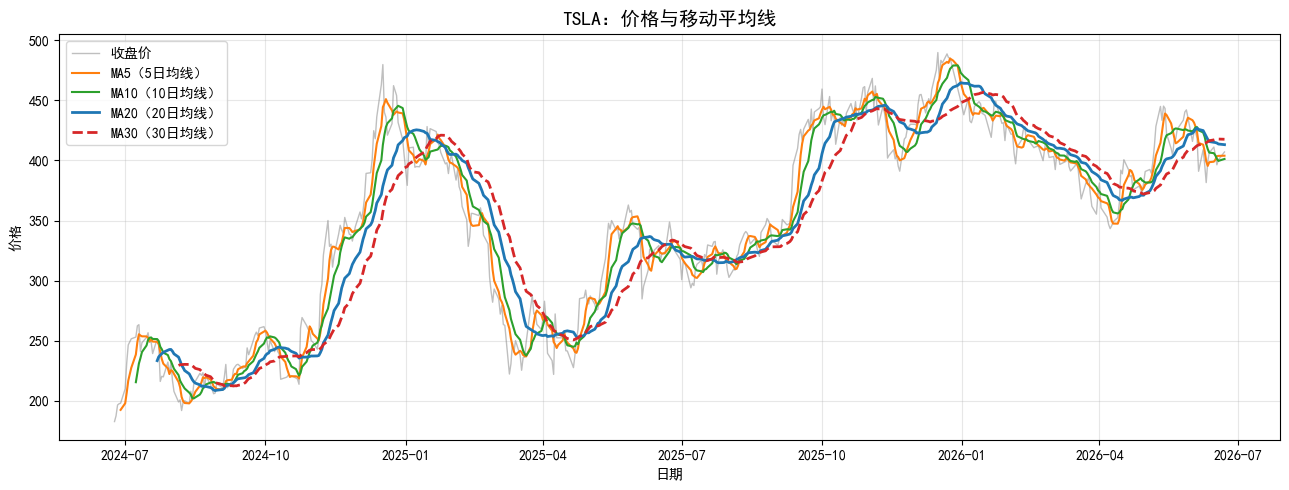

In [31]:
# ========== 画收盘价 + 四条均线 ==========
plt.figure(figsize=(13, 5))
plt.plot(df.index, df['Close'], label='收盘价', color='gray', alpha=0.5, linewidth=1)
plt.plot(df.index, df['MA5'], label='MA5（5日均线）', color='tab:orange', linewidth=1.5)
plt.plot(df.index, df['MA10'], label='MA10（10日均线）', color='tab:green', linewidth=1.5)
plt.plot(df.index, df['MA20'], label='MA20（20日均线）', color='tab:blue', linewidth=2)
plt.plot(df.index, df['MA30'], label='MA30（30日均线）', color='tab:red', linewidth=2, linestyle='--')
plt.title(f'{TICKER}：价格与移动平均线', fontsize=14)
plt.xlabel('日期')
plt.ylabel('价格')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

### 3.4 双均线交叉（本章高潮）

当 **短期均线** 和 **长期均线** 放在一起，会出现两种经典形态：

| 名称 | 发生了什么 | 市场直觉 |
|------|------------|----------|
| **金叉** | 短均线 **从下往上** 穿过长均线 | 短期变强，常被看作 **偏多 / 买入信号** |
| **死叉** | 短均线 **从上往下** 穿过长均线 | 短期变弱，常被看作 **偏空 / 卖出信号** |

> 注意：金叉/死叉是 **描述交叉现象** 的用语，不等于「一定赚钱」——后面章节会做回测验证。

你可以自由选择用哪两条均线做交叉测试（默认 MA5 vs MA20，也可以试试 MA5 vs MA30、MA20 vs MA30 等组合）。

下面在图上标出每一个金叉、死叉的位置。

In [32]:
# ========== 检测金叉、死叉 ==========
df['spread'] = df[SHORT_MA] - df[LONG_MA]              # 短均线减长均线
df['cross'] = np.sign(df['spread']).diff()         # 符号变化：正=金叉，负=死叉

golden = df[df['cross'] > 0].dropna(subset=[SHORT_MA, LONG_MA])  # 金叉那些天
death = df[df['cross'] < 0].dropna(subset=[SHORT_MA, LONG_MA])    # 死叉那些天

print(f'样本期内 金叉 {len(golden)} 次，死叉 {len(death)} 次')
print('\n最近 3 次金叉日期：')
print(golden.tail(3).index.strftime('%Y-%m-%d').tolist())
print('\n最近 3 次死叉日期：')
print(death.tail(3).index.strftime('%Y-%m-%d').tolist())


样本期内 金叉 12 次，死叉 13 次

最近 3 次金叉日期：
['2025-10-21', '2025-12-02', '2026-04-16']

最近 3 次死叉日期：
['2025-11-10', '2026-01-02', '2026-06-04']


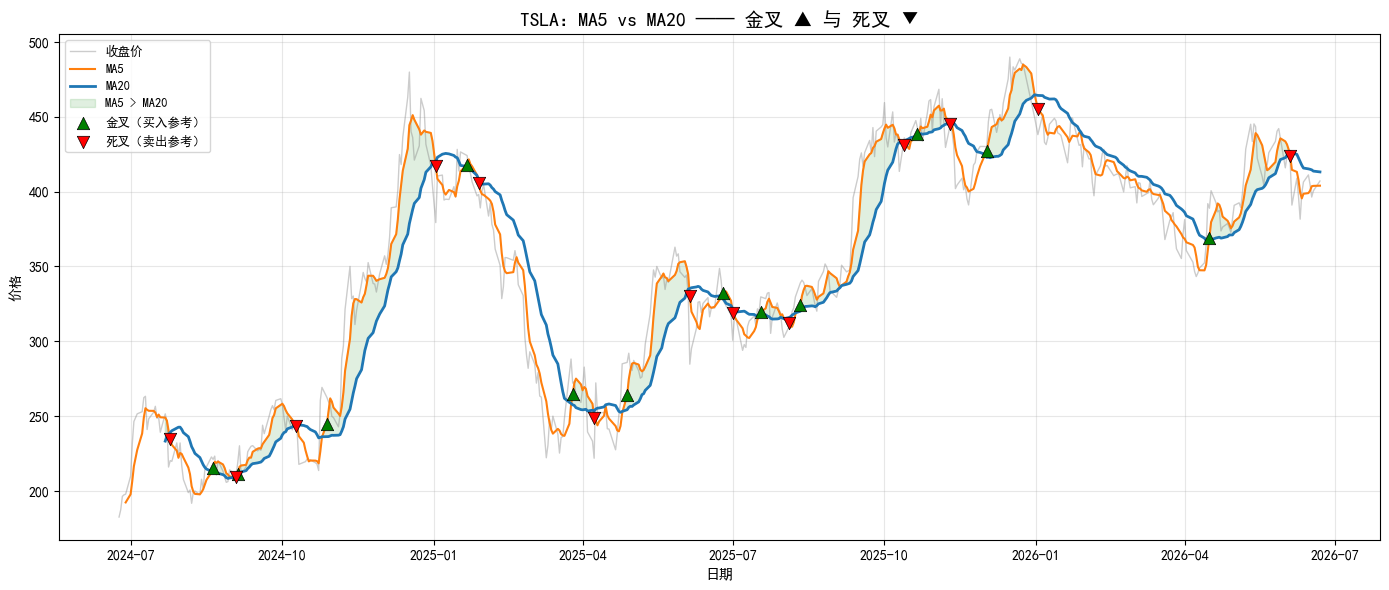

In [33]:
# ========== 金叉死叉标注图 ==========
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['Close'], color='gray', alpha=0.4, linewidth=1, label='收盘价')
ax.plot(df.index, df[SHORT_MA], color='tab:orange', linewidth=1.5, label=SHORT_MA)
ax.plot(df.index, df[LONG_MA], color='tab:blue', linewidth=2, label=LONG_MA)

ax.fill_between(df.index, df[SHORT_MA], df[LONG_MA],
                where=(df[SHORT_MA] >= df[LONG_MA]),
                interpolate=True, alpha=0.12, color='green', label=f'{SHORT_MA} > {LONG_MA}')

ax.scatter(golden.index, golden[SHORT_MA], marker='^', s=80, color='green',
           edgecolors='black', linewidths=0.5, zorder=5, label='金叉（买入参考）')
ax.scatter(death.index, death[SHORT_MA], marker='v', s=80, color='red',
           edgecolors='black', linewidths=0.5, zorder=5, label='死叉（卖出参考）')

ax.set_title(f'{TICKER}：{SHORT_MA} vs {LONG_MA} —— 金叉 ▲ 与 死叉 ▼', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('价格')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

### 3.5 你的第一个策略

把上面的直觉写成 **可执行的规则**（伪代码）：

```text
如果 短均线 > 长均线:
    持有 / 买入
否则:
    空仓 / 卖出
```

这就是著名的 **双均线策略（Moving Average Crossover）** 的最简版本。

在 pandas 里，`signal = 1` 表示持仓，`0` 表示空仓：

In [34]:
# ========== 第一个策略：SHORT_MA > LONG_MA 则持仓 ==========
df['signal'] = (df[SHORT_MA] > df[LONG_MA]).astype(int)  # 满足条件=1，否则=0

df['trade'] = 0                              # 默认无交易
df.loc[df['cross'] > 0, 'trade'] = 1         # 金叉日标记买入
df.loc[df['cross'] < 0, 'trade'] = -1        # 死叉日标记卖出

hold_days = df['signal'].sum()             # signal=1 的天数
buy_count = (df['trade'] == 1).sum()       # 买入信号次数
sell_count = (df['trade'] == -1).sum()     # 卖出信号次数
print(f'规则：{SHORT_MA} > {LONG_MA} 则持仓 (signal=1)')
print(f'样本期内约 {hold_days} 个交易日处于持仓状态（共 {len(df)} 天）')
print(f'共产生 { buy_count + sell_count } 次调仓信号（买 {buy_count} 次 + 卖 {sell_count} 次）')

display(df[df['trade'] != 0][['Close', SHORT_MA, LONG_MA, 'signal', 'trade']].tail(6))


规则：MA5 > MA20 则持仓 (signal=1)
样本期内约 251 个交易日处于持仓状态（共 500 天）
共产生 25 次调仓信号（买 12 次 + 卖 13 次）


,Close,MA5,MA20,signal,trade
Date,,,,,
2025-10-21,442.600006,438.647998,437.611998,1,1
2025-11-10,445.230011,445.398004,445.532501,0,-1
2025-12-02,429.239990,427.106000,422.867001,1,1
2026-01-02,438.070007,455.410004,464.267003,0,-1
2026-04-16,388.899994,369.284009,366.783501,1,1
2026-06-04,418.450012,423.512006,426.911501,0,-1


**恭喜你** —— 你已经把「看盘感觉」写成了 **if 判断 + 表格列**，这就是量化策略的起点。

真实交易还要考虑手续费、滑点、能否当天成交等；**第四章回测** 会帮你用数据检验「这套规则到底赚没赚」。

小提示：为避免 **未来函数**，回测时常用 `signal.shift(1)`——今天收盘算出的信号，明天才能按它交易。本章先聚焦「规则与可视化」。

---

### 3.6 可视化策略信号（非常重要）

一张好的策略图应让人 **一眼看懂**：

- 价格 + 两条均线（你选择的短均线和长均线）
- **绿色 ▲** = 买入点（金叉）
- **红色 ▼** = 卖出点（死叉）
- 下方色带 = 当前是持仓还是空仓

这类图会让你的 Notebook 立刻有「专业量化报告」的味道。

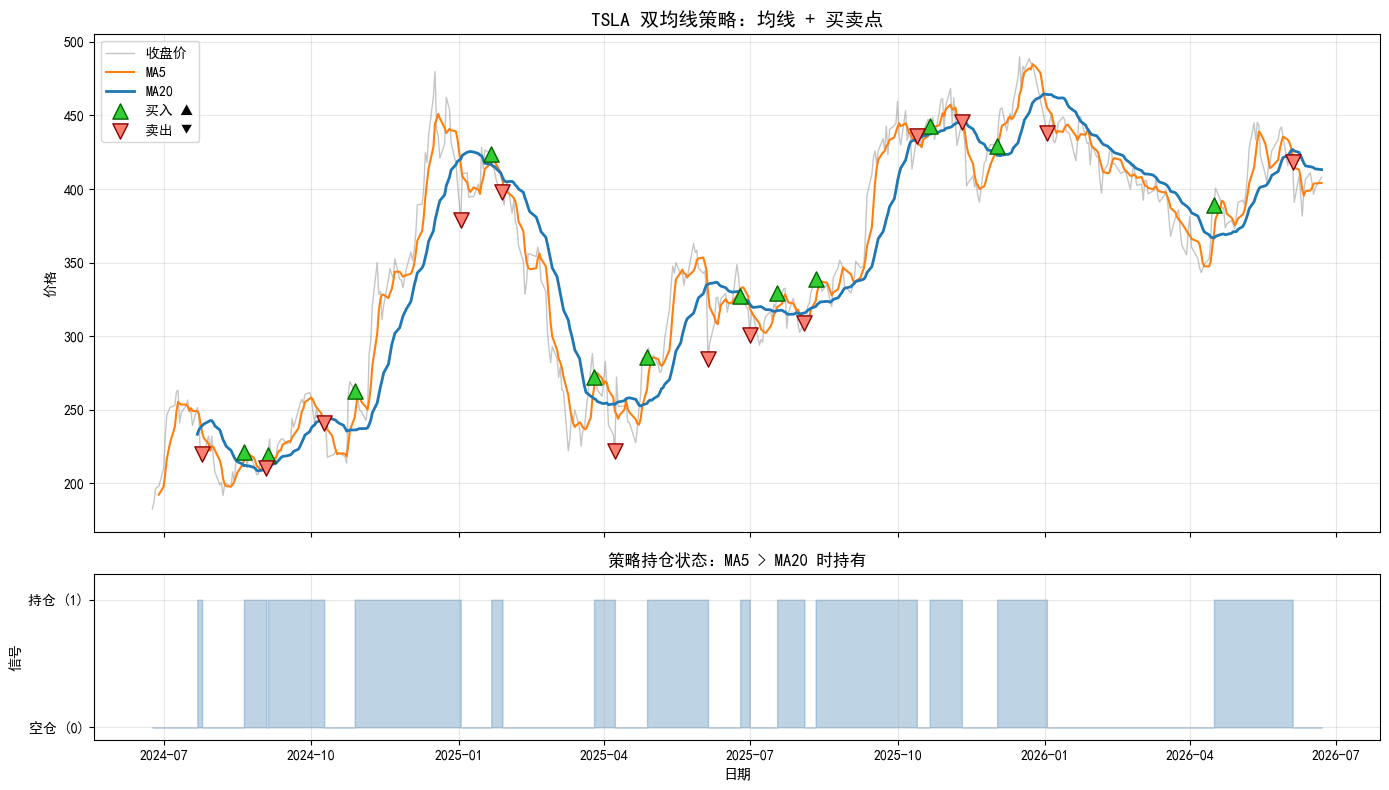

In [26]:
# ========== 策略信号大图：价格+买卖点+持仓条 ==========
buys = df[df['trade'] == 1]    # 所有买入日
sells = df[df['trade'] == -1]  # 所有卖出日

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax_price, ax_pos = axes

ax_price.plot(df.index, df['Close'], color='gray', alpha=0.45, linewidth=1, label='收盘价')
ax_price.plot(df.index, df[SHORT_MA], color='tab:orange', linewidth=1.5, label=SHORT_MA)
ax_price.plot(df.index, df[LONG_MA], color='tab:blue', linewidth=2, label=LONG_MA)

ax_price.scatter(buys.index, buys['Close'], marker='^', s=120, color='limegreen',
                 edgecolors='darkgreen', linewidths=1, zorder=6, label='买入 ▲')
ax_price.scatter(sells.index, sells['Close'], marker='v', s=120, color='salmon',
                 edgecolors='darkred', linewidths=1, zorder=6, label='卖出 ▼')

ax_price.set_title(f'{TICKER} 双均线策略：均线 + 买卖点（{SHORT_MA} vs {LONG_MA}）', fontsize=14)
ax_price.set_ylabel('价格')
ax_price.legend(loc='upper left')
ax_price.grid(True, alpha=0.3)

ax_pos.fill_between(df.index, 0, df['signal'], step='post', alpha=0.35, color='steelblue')
ax_pos.set_ylim(-0.1, 1.2)
ax_pos.set_yticks([0, 1])
ax_pos.set_yticklabels(['空仓 (0)', '持仓 (1)'])
ax_pos.set_xlabel('日期')
ax_pos.set_ylabel('信号')
ax_pos.set_title(f'策略持仓状态：{SHORT_MA} > {LONG_MA} 时持有', fontsize=12)
ax_pos.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


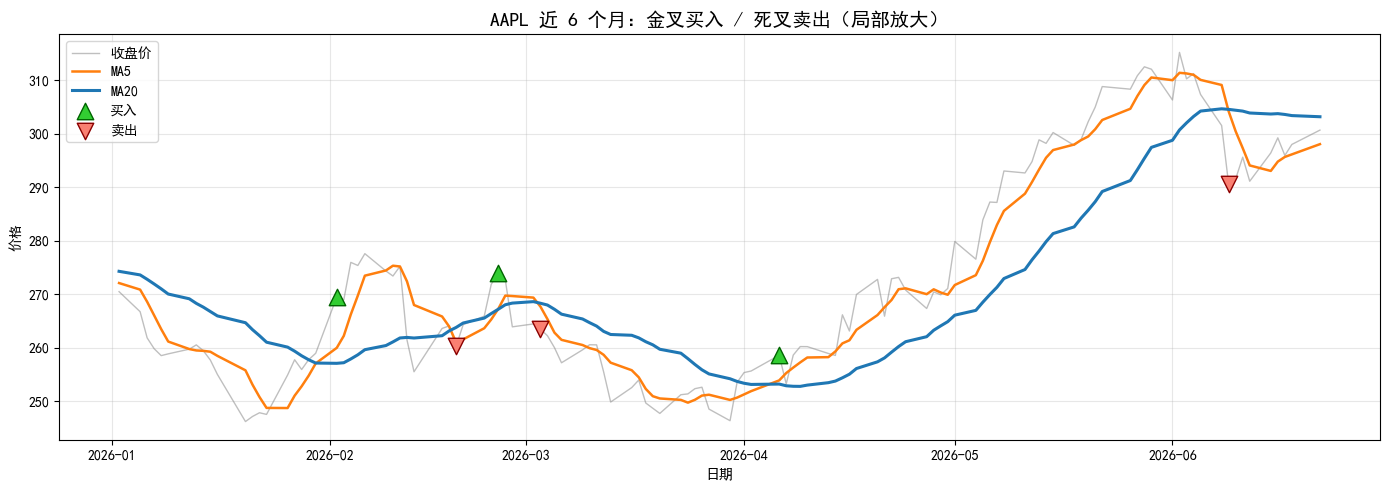

In [16]:
# ========== 放大最近6个月，看清买卖细节 ==========
recent = df.last('6M') if len(df) > 120 else df.tail(120)  # 取最近约6个月
buys_r = recent[recent['trade'] == 1]
sells_r = recent[recent['trade'] == -1]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(recent.index, recent['Close'], color='gray', alpha=0.5, linewidth=1, label='收盘价')
ax.plot(recent.index, recent[SHORT_MA], color='tab:orange', linewidth=1.8, label=SHORT_MA)
ax.plot(recent.index, recent[LONG_MA], color='tab:blue', linewidth=2.2, label=LONG_MA)
ax.scatter(buys_r.index, buys_r['Close'], marker='^', s=140, color='limegreen',
           edgecolors='darkgreen', linewidths=1, zorder=6, label='买入')
ax.scatter(sells_r.index, sells_r['Close'], marker='v', s=140, color='salmon',
           edgecolors='darkred', linewidths=1, zorder=6, label='卖出')
ax.set_title(f'{TICKER} 近 6 个月：金叉买入 / 死叉卖出（{SHORT_MA} vs {LONG_MA}）', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('价格')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

## 🎯 挑战任务（第三章通关）

1. 把 `TICKER` 改成 **`'TSLA'`**，截一张带 **金叉▲ / 死叉▼** 的图——这就是你的第一张「策略信号图」。  
2. 修改 `SHORT_MA` 和 `LONG_MA`，试试 **MA5 vs MA30**、**MA10 vs MA30** 等组合，和 MA5/MA20 比：买卖次数变多了还是变少了？  
3. **思考题**：金叉一定赚钱吗？为什么第四章要做回测？

---

## 本章总结

- **趋势** 是大方向；**噪声** 是短期乱动；均线用来「磨平」噪声。  
- $MA_n$ = 最近 n 天收盘价的平均；`rolling(n).mean()` 即可计算。  
- **金叉**（短均线上穿长均线）≈ 买入参考；**死叉** ≈ 卖出参考。  
- 你的第一个策略：`signal = (短均线 > 长均线)` —— 你已经写出 **交易系统** 了。  
- 策略图 = 均线 + 买卖点 + 持仓色带，专业感来自 **可视化**。

**下一章预告**：第四章 **策略回测** —— 用历史数据回答：这套双均线规则，到底赚没赚钱？最大回撤有多大？